# CÍL 5: Matplotlib

> Tento notebook je součástí cvičení 12 předmětu BPC-PRG.  
> Projdi ho postupně – každou buňku spusť klávesou **Shift+Enter**.  
> 📥 **[Stáhnout notebook](cviceni_12_matplotlib.ipynb)** &nbsp;|&nbsp; 📥 **[Stáhnout data (mpl_data.npz)](../mpl_data.npz)**


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Všechna data jsou předpřipravena – stáhni mpl_data.npz a načti:
d = np.load("mpl_data.npz")

t, ekg, resp        = d["t"], d["ekg"], d["resp"]
mri                 = d["mri"]
zatez               = [d["klid"], d["chuze"], d["beh"], d["sprint"]]
zdravi, diabetici   = d["zdravi"], d["diabetici"]

# Zátěžový test: tf_test.shape == (30, 60)
# 30 pacientů měřených každou minutu po dobu 60 minut
# Fáze:  Klid 0–9 min | Zahřívání 10–19 | Aerobní 20–39 | Sprint 40–49 | Regenerace 50–59
tf_test = d["tf_test"]


## Co je Matplotlib?

[**Matplotlib**](https://matplotlib.org/) je nejrozšířenější Python knihovna pro tvorbu grafů a vizualizací. Vznikla v roce 2003 jako náhrada za grafiku MATLABu – odtud jméno.

Její hlavní modul, který budeš téměř vždy importovat, se jmenuje **`pyplot`**. Poskytuje rozhraní inspirované MATLABem a umožňuje tvorbu grafů několika řádky kódu.

V biomedicíně ji využiješ na:

- vykreslení **časových řad** (EKG, dech, krevní tlak, teplota),
- zobrazení **medicínských snímků** (MRI, CT, histologické řezy) jako 2D matice,
- **statistické grafy** – boxploty pro srovnání skupin pacientů, histogramy pro rozložení hodnot,
- **vědecké publikace** – výstup ve formátu PDF/SVG s přesnou kontrolou nad každým detailem.

Matplotlib je úzce provázaný s NumPy – jako data přijímají funkce přímo numpy pole.

### Co vše lze vykreslit?

| Typ grafu          | Funkce         | Kdy ho použít                                       |
|--------------------|----------------|-----------------------------------------------------|
| Spojnicový         | `ax.plot()`    | Časové řady – EKG, dech, průběh léčby               |
| Sloupcový          | `ax.bar()`     | Srovnání kategorií – průměry skupin, výsledky měření |
| Bodový (scatter)   | `ax.scatter()` | Korelace dvou proměnných – výška vs váha            |
| Histogram          | `ax.hist()`    | Rozložení hodnot – glykémie, BMI, TF                |
| Boxplot            | `ax.boxplot()` | Mediány a rozptyl napříč skupinami pacientů         |
| Obrázek / heatmapa | `ax.imshow()`  | MRI, CT snímky, korelační matice                    |
| Výsečový           | `ax.pie()`     | Podíly – zastoupení diagnóz v populaci              |

> **Poznámka:** Pro interaktivní a webové grafy existují moderní alternativy jako **Plotly** nebo **Bokeh**. Matplotlib je ale základ, na kterém jsou postavené i vyšší knihovny jako **Seaborn** nebo **Pandas** `.plot()`.

## 3.1 Základní struktura matplotlib

Matplotlib má dvě vrstvy rozhraní:

- **`plt.plot()`** – rychlé globální funkce, dobré pro jeden jednoduchý graf,
- **`fig, ax = plt.subplots()`** – přímá práce s objekty Figure a Axes; doporučovaný přístup jakmile máš víc grafů nebo potřebuješ přesnou kontrolu.

Budeme používat druhý přístup – je přehlednější a lépe se škáluje na složitější vizualizace.

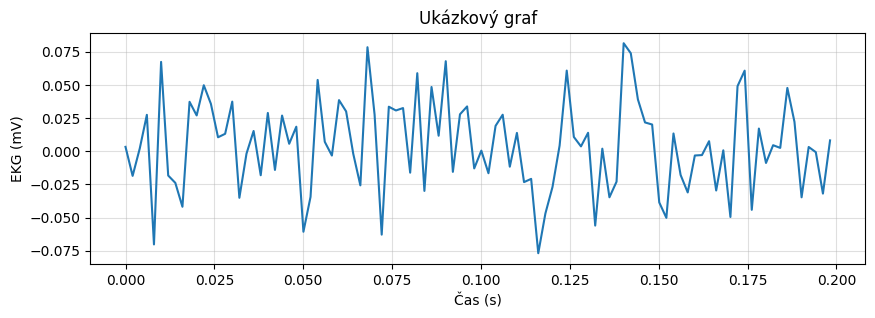

In [2]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t[:100], ekg[:100])
ax.set_title("Ukázkový graf")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.grid(True, alpha=0.4)
plt.show()


## 3.2 Vykreslení signálu

Spojnicový graf je základní vizualizace pro časové řady – EKG, dech, krevní tlak, teplota.

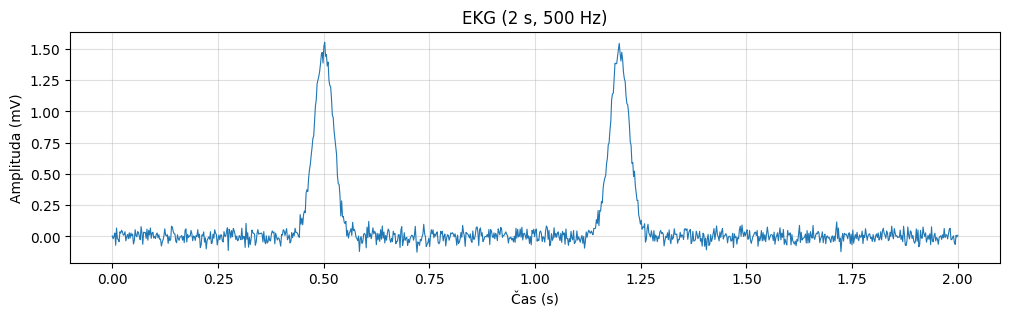

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_title("EKG (2 s, 500 Hz)")
ax.set_xlabel("Čas (s)")
ax.set_ylabel("Amplituda (mV)")
ax.grid(True, alpha=0.4)
plt.show()


### Více grafů pod sebou – `sharex=True`

`plt.subplots(2, 1, sharex=True)` vytvoří dva grafy sdílející osu X – ideální pro srovnání více kanálů (EKG + dech, EKG + tlak apod.).

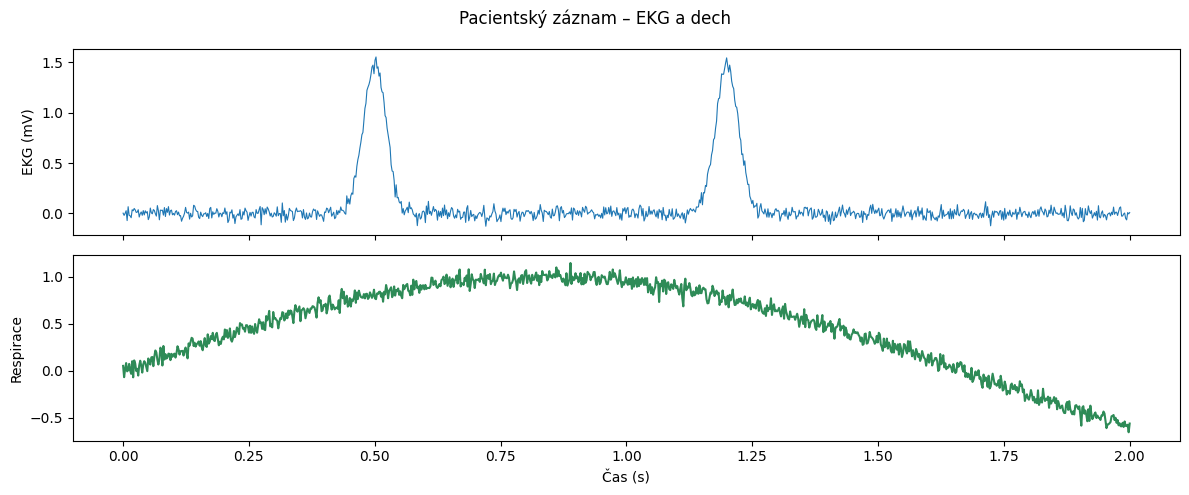

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t, ekg, linewidth=0.8)
ax1.set_ylabel("EKG (mV)")
ax2.plot(t, resp, color="seagreen")
ax2.set_ylabel("Respirace")
ax2.set_xlabel("Čas (s)")
fig.suptitle("Pacientský záznam – EKG a dech")
plt.tight_layout()
plt.show()


## 3.3 Zobrazení matice / obrazu

`imshow()` zobrazí 2D numpy pole jako obrázek nebo heatmapu – každá hodnota odpovídá barvě pixelu. Hodí se pro medicínské snímky (MRI, CT), korelační matice nebo síťové váhy v neuronových sítích.

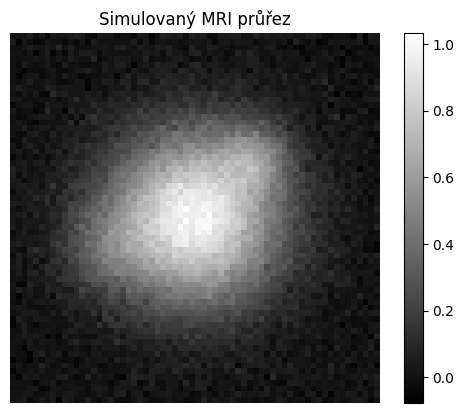

In [5]:
fig, ax = plt.subplots()
im = ax.imshow(mri, cmap="gray")
fig.colorbar(im)
ax.axis("off")
ax.set_title("Simulovaný MRI průřez")
plt.show()


> **Tip:** Pro medicínské obrazy se nejčastěji používá `cmap="gray"`. `viridis` je dobrou volbou pro vědecké heatmapy – je perceptuálně uniformní (stejné rozdíly v datech odpovídají stejně vnímaným rozdílům v barvě) a čitelná i při výtisku nebo pro barvoslepé.

### 3.3.1 Srovnání colormap

Různé colormapy sdělují data různě. Porovnej tři klasické volby na stejném snímku:

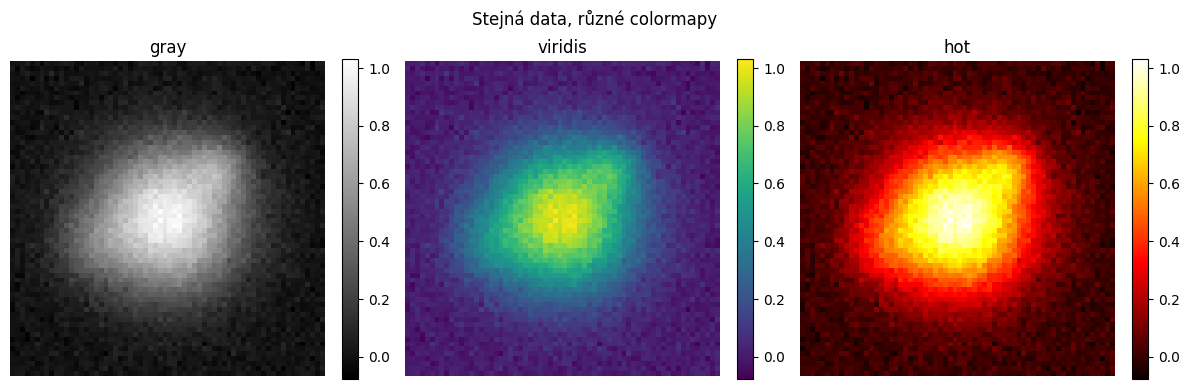

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, cmap in zip(axes, ["gray", "viridis", "hot"]):
    im = ax.imshow(mri, cmap=cmap)
    ax.set_title(cmap)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Stejná data, různé colormapy")
plt.tight_layout()
plt.show()

## 3.4 Boxplot – statistické srovnání skupin

Boxplot je ideální pro srovnání rozložení hodnot napříč skupinami – různé pacienty, různé podmínky měření, různé diagnózy. Ukazuje medián, kvartily, vousy a odlehlé hodnoty.

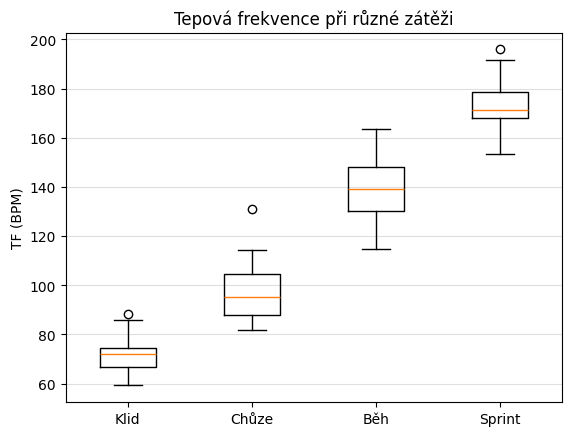

In [7]:
fig, ax = plt.subplots()
ax.boxplot(zatez, tick_labels=["Klid", "Chůze", "Běh", "Sprint"])
ax.set_title("Tepová frekvence při různé zátěži")
ax.set_ylabel("TF (BPM)")
ax.grid(True, axis="y", alpha=0.4)
plt.show()


## 3.5 Histogram – rozložení hodnot

Histogram ukazuje, jak jsou hodnoty rozloženy. Hodí se pro první pohled na data – je rozložení symetrické? Má odlehlé hodnoty? Odpovídá normálnímu rozložení?

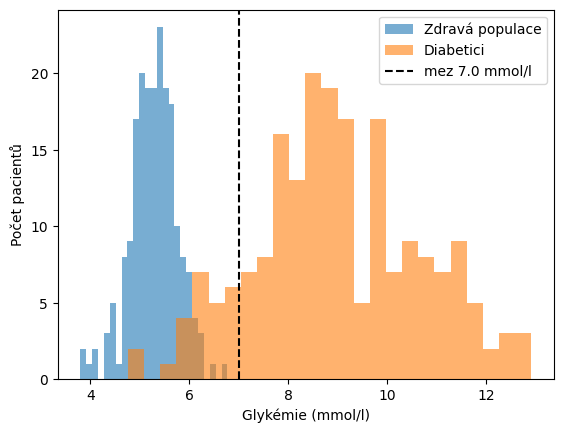

In [8]:
fig, ax = plt.subplots()
ax.hist(zdravi,    bins=25, alpha=0.6, label="Zdravá populace")
ax.hist(diabetici, bins=25, alpha=0.6, label="Diabetici")
ax.axvline(7.0, color="black", linestyle="--", label="mez 7.0 mmol/l")
ax.set_xlabel("Glykémie (mmol/l)")
ax.set_ylabel("Počet pacientů")
ax.legend()
plt.show()


---

## ÚKOL: Zátěžový test – analýza a vizualizace

Data `tf_test` jsou již načtena v nastavovací buňce.  
Jde o matici **30 pacientů × 60 minut** tepové frekvence (BPM) z protokolu:

| Fáze       | Minuty |
|------------|--------|
| Klid       | 0–9    |
| Zahřívání  | 10–19  |
| Aerobní    | 20–39  |
| Sprint     | 40–49  |
| Regenerace | 50–59  |

**1. Průměrný signál v čase**  
Vypočítej průměrnou TF napříč pacienty pro každou minutu a vykresli jako spojnicový graf.
Osa X = minuty (0–59), osa Y = TF (BPM). Přidej nadpis a popsané osy.

**2. Boxplot pro každou fázi**
Pro každou fázi vezmi hodnoty všech pacientů a všech minut (`tf_test[:, 0:10].ravel()` atd.) a vykresli boxplot pěti skupin.  
Popisky: `["Klid", "Zahřívání", "Aerobní", "Sprint", "Regenerace"]`.

**3. Histogram – klid vs sprint**
Do jednoho histogramu vykresli hodnoty fáze Klid a fáze Sprint.
Přidej legendu a popsané osy.

**4.** Ke každému grafu přidej markdownovou buňku s jednou větou – co graf ukazuje.


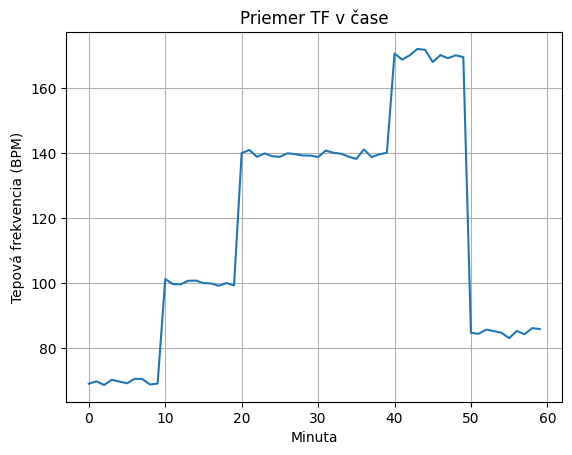

C:\Users\283206\AppData\Local\Temp\ipykernel_10636\3965010306.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([klid, zahrivani, aerobni, sprint, regenerace],


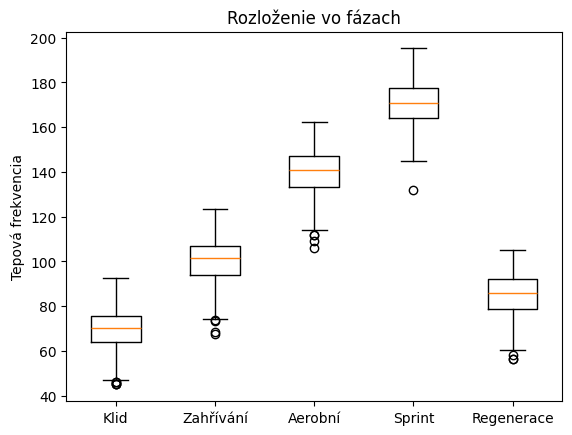

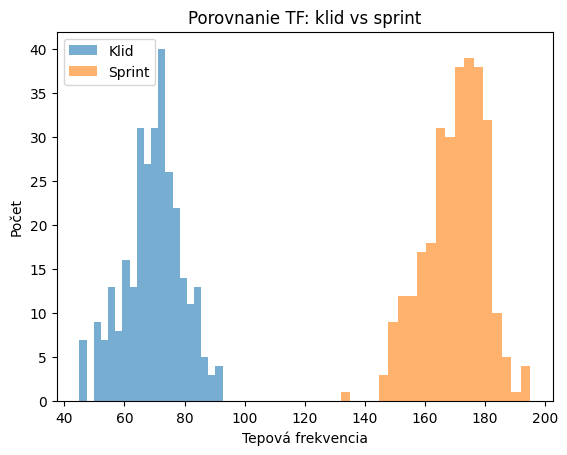

In [12]:
# tf_test.shape == (30, 60)
# Fáze: Klid 0–9, Zahřívání 10–19, Aerobní 20–39, Sprint 40–49, Regenerace 50–59

# 1. Průměrná TF v čase (signál)
mean_tf = np.mean(tf_test, axis=0)

plt.figure()
plt.plot(range(60), mean_tf)
plt.xlabel("Minuta")
plt.ylabel("Tepová frekvencia (BPM)")
plt.title("Priemer TF v čase")
plt.grid()

plt.show()

# 2. Boxplot – 5 fází
faze_data   = [tf_test[:, 0:10].ravel(), tf_test[:, 10:20].ravel(),
               tf_test[:, 20:40].ravel(), tf_test[:, 40:50].ravel(),
               tf_test[:, 50:60].ravel()]
faze_labels = ["Klid", "Zahřívání", "Aerobní", "Sprint", "Regenerace"]

klid = tf_test[:, 0:10].ravel()
zahrivani = tf_test[:, 10:20].ravel()
aerobni = tf_test[:, 20:40].ravel()
sprint = tf_test[:, 40:50].ravel()
regenerace = tf_test[:, 50:60].ravel()

plt.figure()
plt.boxplot([klid, zahrivani, aerobni, sprint, regenerace],
            labels=["Klid", "Zahřívání", "Aerobní", "Sprint", "Regenerace"])

plt.ylabel("Tepová frekvencia")
plt.title("Rozloženie vo fázach")

plt.show()
# 3. Histogram – klid vs sprint
plt.figure()

plt.hist(klid, bins=20, alpha=0.6, label="Klid")
plt.hist(sprint, bins=20, alpha=0.6, label="Sprint")

plt.xlabel("Tepová frekvencia")
plt.ylabel("Počet")
plt.title("Porovnanie TF: klid vs sprint")
plt.legend()

plt.show()
